In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

resumeDataSet = pd.read_csv('UpdatedResumeDataSet.csv' ,encoding='utf-8')
resumeDataSet['cleaned_resume'] = ''
print(resumeDataSet.shape)
resumeDataSet.head()


(962, 3)


,Category,Resume,cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",


In [2]:
print ("Displaying the distinct categories of resume -")
print (resumeDataSet['Category'].unique())

Displaying the distinct categories of resume -
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [3]:
print ("Displaying the distinct categories of resume and the number of records belonging to each category -")
print (resumeDataSet['Category'].value_counts())

Displaying the distinct categories of resume and the number of records belonging to each category -
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: Category, dtype: int64


<AxesSubplot:xlabel='count', ylabel='Category'>

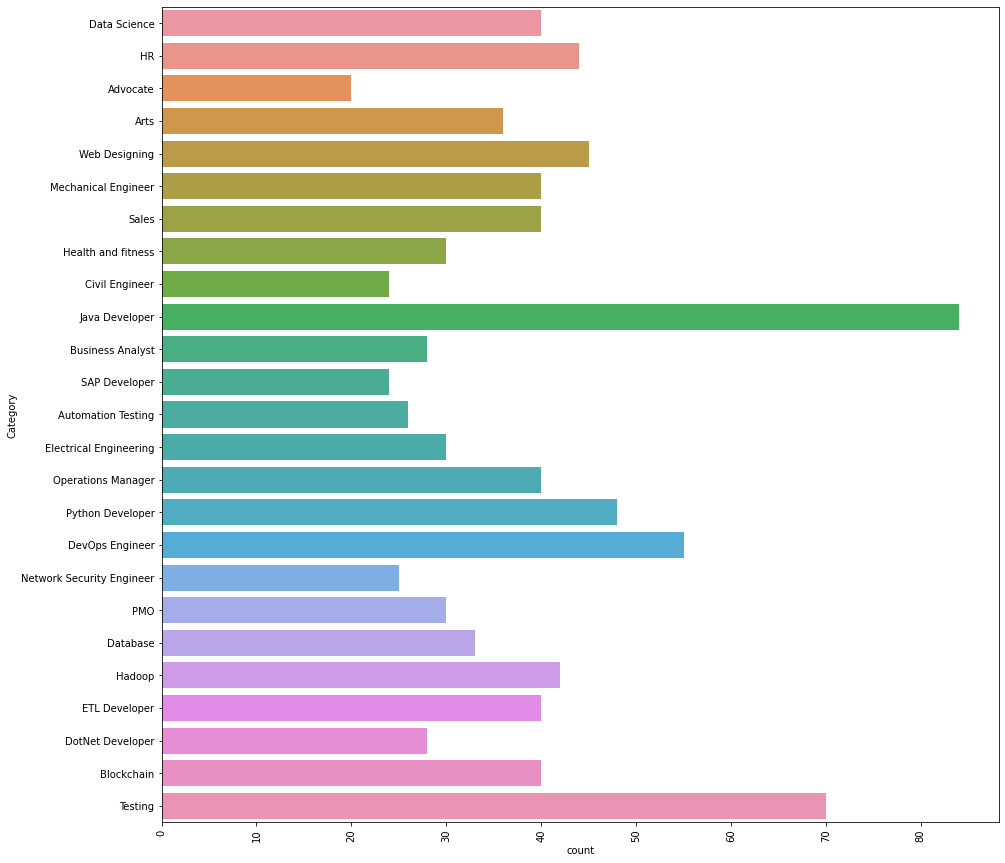

In [4]:
import seaborn as sns
plt.figure(figsize=(15,15))
plt.xticks(rotation=90)
sns.countplot(y="Category", data=resumeDataSet)

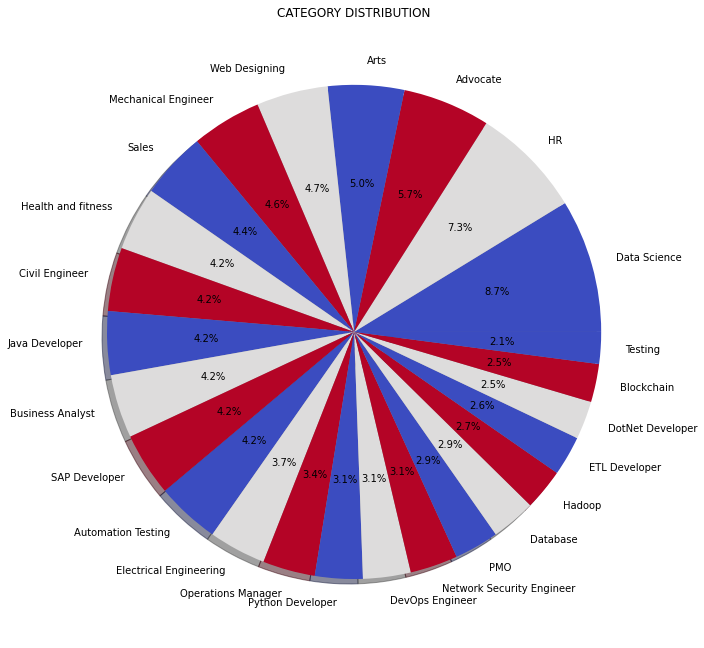

In [5]:
from matplotlib.gridspec import GridSpec
targetCounts = resumeDataSet['Category'].value_counts()
targetLabels  = resumeDataSet['Category'].unique()
# Make square figures and axes
plt.figure(1, figsize=(25,25))
the_grid = GridSpec(2, 2)


cmap = plt.get_cmap('coolwarm')
colors = [cmap(i) for i in np.linspace(0, 1, 3)]
plt.subplot(the_grid[0, 1], aspect=1, title='CATEGORY DISTRIBUTION')

source_pie = plt.pie(targetCounts, labels=targetLabels, autopct='%1.1f%%', shadow=True, colors=colors)
plt.show()

In [6]:
import re
def cleanResume(resumeText):
    resumeText = re.sub('http\S+\s*', ' ', resumeText)  # remove URLs
    resumeText = re.sub('RT|cc', ' ', resumeText)  # remove RT and cc
    resumeText = re.sub('#\S+', '', resumeText)  # remove hashtags
    resumeText = re.sub('@\S+', '  ', resumeText)  # remove mentions
    resumeText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', resumeText)  # remove punctuations
    resumeText = re.sub(r'[^\x00-\x7f]',r' ', resumeText) 
    resumeText = re.sub('\s+', ' ', resumeText)  # remove extra whitespace
    return resumeText

In [7]:
resumeDataSet['cleaned_resume'] = resumeDataSet.Resume.apply(lambda x: cleanResume(x))
print (resumeDataSet['cleaned_resume'][31])

Education Details May 2013 to May 2017 B E UIT RGPV Data Scientist Data Scientist Matelabs Skill Details Python Exprience Less than 1 year months Statsmodels Exprience 12 months AWS Exprience Less than 1 year months Machine learning Exprience Less than 1 year months Sklearn Exprience Less than 1 year months Scipy Exprience Less than 1 year months Keras Exprience Less than 1 year monthsCompany Details company Matelabs description ML Platform for business professionals dummies and enthusiasts 60 A Koramangala 5th block Achievements Tasks behind sukh sagar Bengaluru India Developed and deployed auto preprocessing steps of machine learning mainly missing value treatment outlier detection encoding scaling feature selection and dimensionality reduction Deployed automated classification and regression model linkedin com in aditya rathore b4600b146 Reasearch and deployed the time series forecasting model ARIMA SARIMAX Holt winter and Prophet Worked on meta feature extracting problem github com

In [8]:
import nltk
from nltk.corpus import stopwords
import string
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download('punkt')

oneSetOfStopWords = set(stopwords.words('english')+['``',"''"])
totalWords =[]
Sentences = resumeDataSet['Resume'].values
cleanedSentences = ""
for i in range(0,160):
    cleanedText = cleanResume(Sentences[i])
    cleanedSentences += cleanedText
    requiredWords = nltk.word_tokenize(cleanedText)
    for word in requiredWords:
        if word not in oneSetOfStopWords and word not in string.punctuation:
            totalWords.append(word)
    
wordfreqdist = nltk.FreqDist(totalWords)
mostcommon = wordfreqdist.most_common(50)
print(mostcommon)

# wc = WordCloud().generate(cleanedSentences)
# plt.figure(figsize=(15,15))
# plt.imshow(wc, interpolation='bilinear')
# plt.axis("off")
# plt.show()

[nltk_data] Downloading package stopwords to C:\Users\Muhammad
[nltk_data]     Darab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Muhammad
[nltk_data]     Darab\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[('Details', 484), ('Exprience', 446), ('months', 376), ('company', 330), ('description', 310), ('1', 290), ('year', 232), ('January', 216), ('Less', 204), ('Data', 200), ('data', 192), ('Skill', 166), ('Maharashtra', 166), ('6', 164), ('Python', 156), ('Science', 154), ('I', 146), ('Education', 142), ('College', 140), ('The', 126), ('project', 126), ('like', 126), ('Project', 124), ('Learning', 116), ('India', 114), ('Machine', 112), ('University', 112), ('Web', 106), ('using', 104), ('monthsCompany', 102), ('B', 98), ('C', 98), ('SQL', 96), ('time', 92), ('learning', 90), ('Mumbai', 90), ('Pune', 90), ('Arts', 90), ('A', 84), ('application', 84), ('Engineering', 78), ('24', 76), ('various', 76), ('Software', 76), ('Responsibilities', 76), ('Nagpur', 76), ('development', 74), ('Management', 74), ('projects', 74), ('Technologies', 72)]


In [9]:
from sklearn.preprocessing import LabelEncoder

var_mod = ['Category']
le = LabelEncoder()
for i in var_mod:
    resumeDataSet[i] = le.fit_transform(resumeDataSet[i])
print ("CONVERTED THE CATEGORICAL VARIABLES INTO NUMERICALS")

CONVERTED THE CATEGORICAL VARIABLES INTO NUMERICALS


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

requiredText = resumeDataSet['cleaned_resume'].values
requiredTarget = resumeDataSet['Category'].values

'''
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    stop_words='english',
    ngram_range=(1, 1),
    max_features=2000)
word_vectorizer.fit(requiredText)
WordFeatures = word_vectorizer.transform(requiredText)

char_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='char',
    stop_words='english',
    ngram_range=(2, 6),
    max_features=2000)
char_vectorizer.fit(requiredText)
CharFeatures = char_vectorizer.transform(requiredText)
totalFeatures = hstack([WordFeatures, CharFeatures])
'''
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    stop_words='english',
    max_features=2000
)
word_vectorizer.fit(requiredText)
WordFeatures = word_vectorizer.transform(requiredText)

print ("Feature completed .....")

X_train,X_test,y_train,y_test = train_test_split(WordFeatures,requiredTarget,random_state=0, test_size=0.2)
print(X_train.shape)
print(X_test.shape)

Feature completed .....
(769, 2000)
(193, 2000)


In [11]:
clf = OneVsRestClassifier(KNeighborsClassifier())
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
print('Accuracy of KNeighbors Classifier on training set: {:.2f}'.format(clf.score(X_train, y_train)))
print('Accuracy of KNeighbors Classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))

print("\n Classification report for classifier %s:\n%s\n" % (clf, metrics.classification_report(y_test, prediction)))
#print("Confusion matrix:\n%s" % metrics.confusion_matrix(y_test, prediction))

Accuracy of KNeighbors Classifier on training set: 0.99
Accuracy of KNeighbors Classifier on test set: 0.99

 Classification report for classifier OneVsRestClassifier(estimator=KNeighborsClassifier()):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00         7
           8       1.00      0.91      0.95        11
           9       1.00      1.00      1.00         9
          10       1.00      1.00      1.00         8
          11       0.90      1.00      0.95         9
          12       1.00      1.00      1.00         5
          13       1.00      1.00      1.

In [12]:
clf = OneVsRestClassifier(MultinomialNB()).fit(X_train, y_train)
prediction = clf.predict(X_test)
print('Accuracy of MultinomialNB Classifier on training set: {:.2f}'.format(clf.score(X_train, y_train)))
print('Accuracy of MultinomialNB Classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))
print("\n Classification report for classifier %s:\n%s\n" % (clf, metrics.classification_report(y_test, prediction)))


Accuracy of MultinomialNB Classifier on training set: 0.99
Accuracy of MultinomialNB Classifier on test set: 0.98

 Classification report for classifier OneVsRestClassifier(estimator=MultinomialNB()):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         5
           6       1.00      0.78      0.88         9
           7       1.00      1.00      1.00         7
           8       1.00      0.91      0.95        11
           9       1.00      1.00      1.00         9
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         9
          12       1.00      1.00      1.00         5
          13       1.00      1.00      1.0

In [13]:
#BEGIN

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.activations import linear, relu, sigmoid, softmax
from keras.utils import to_categorical
import scipy

In [15]:
X_train_A = scipy.sparse.csr_matrix.toarray(X_train)
X_test_A = scipy.sparse.csr_matrix.toarray(X_test)
y_train_A = to_categorical(y_train, 25)
y_test_A = to_categorical(y_test, 25)

In [16]:
print(X_train_A.shape, X_test_A.shape, y_train_A.shape, y_test_A.shape)
print(y_train_A[1])

(769, 2000) (193, 2000) (769, 25) (193, 25)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [17]:
model = Sequential ([
    Input(shape = (X_train_A.shape[1],)),
    Dense(units = 180, activation = 'relu'),
    Dense(units = 90, activation = 'relu'),
    Dense(units = 45, activation = 'relu'),
    Dense(units = 25, activation = 'softmax'),
])
model.compile (
    loss = tf.keras.losses.CategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics = ['Accuracy']
)
model.fit(
    X_train_A, y_train_A,
    epochs = 8,
    batch_size = 128,
)

Epoch 1/8
7/7 [==============================] - 3s 13ms/step - loss: 2.8238 - Accuracy: 0.1899
Epoch 2/8
7/7 [==============================] - 0s 11ms/step - loss: 0.9346 - Accuracy: 0.8010
Epoch 3/8
7/7 [==============================] - 0s 11ms/step - loss: 0.0656 - Accuracy: 0.9896
Epoch 4/8
7/7 [==============================] - 0s 11ms/step - loss: 0.0077 - Accuracy: 1.0000
Epoch 5/8
7/7 [==============================] - 0s 10ms/step - loss: 0.0027 - Accuracy: 1.0000
Epoch 6/8
7/7 [==============================] - 0s 11ms/step - loss: 2.7056e-04 - Accuracy: 1.0000
Epoch 7/8
7/7 [==============================] - 0s 9ms/step - loss: 1.0615e-04 - Accuracy: 1.0000
Epoch 8/8
7/7 [==============================] - 0s 11ms/step - loss: 8.1596e-05 - Accuracy: 1.0000


In [18]:
predictions = model.predict(X_test_A)

7/7 [==============================] - 0s 7ms/step


In [19]:
def maxArray(predi):
    pred = []
    for i in range(predi.shape[0]):
        pred.append(np.argmax(predi[i]))
    return pred

In [20]:
pred = maxArray(predictions)

In [21]:
def Accuracy(Y_, Y):
    accuracy = 0
    for i in range(len(Y)):
        if Y_[i] == Y[i]:
            accuracy += 1
    accuracy = accuracy / len(Y)
    return accuracy

In [22]:
accuracy = Accuracy(pred, y_test)
print("Test has accuracy of", accuracy * 100, '%')

Test has accuracy of 99.48186528497409 %


In [28]:
#BEGIN TEST ON INPUTTED RESUME

In [29]:
vec_Con = scipy.sparse.csr_matrix.toarray(vectored_content)

In [30]:
vec_Con_Predictions = model.predict(vec_Con)
vec_Con_Pred = maxArray(vec_Con_Predictions)
print('Inputted Resume has Category ', vec_Con_Pred, le.classes_[vec_Con_Pred])

1/1 [==============================] - 0s 39ms/step
Inputted Resume has Category  [21] ['SAP Developer']


In [ ]:
#END TEST ON INPUTTED RESUME

In [ ]:
#END

# Testing A Resume

In [23]:
import PyPDF3
   
# creating a pdf file object
file = "resume3.pdf"
with open(file, 'rb') as pdfFileObj:
	# creating a pdf reader object
	pdfReader = PyPDF3.PdfFileReader(pdfFileObj)
	
	# printing number of pages in pdf file
	print(pdfReader.numPages)
	
	# creating a page object
	pageObj = pdfReader.getPage(0)
	
	# extracting text from page
	content = pageObj.extractText()

2


In [24]:
cleaned_content = cleanResume(content)
cleaned_content

' 4567 Main Street Detroit Michigan 48127 313 555 0100 d robbbins www linkedin com in drobbins Analytical organized and detail oriented a ountant with GAAP expertise and experience in the full spectrum of public a ounting Collaborative team player with ownership mentality and a track record of delivering the highest quality strategic solutions to resolve challenges propel business growth EXPERIENCE 2014 TO PRESENT ACCOUNTANT ABC INCORPORATED MOUNTAIN MICHIGAN Working in a mid sized public a ounting firm to provide professional a ounting services for individuals and business clients Provide full range of services include income tax preparation audit support preparation of financial statements pro forma budgeting general ledger a ounting and bank reconciliation Su ess Examples significant tax penalties for two real estate development projects Led financial due diligence to evaluate a proposed 30M acquisition for real estate development company and saved the client from makin g a poor inv

In [25]:
vectored_content = word_vectorizer.transform([cleaned_content])
vectored_content

<1x2000 sparse matrix of type '<class 'numpy.float64'>'
	with 72 stored elements in Compressed Sparse Row format>

In [26]:
pred = clf.predict(vectored_content)[0]
pred

18

In [27]:
pred, le.classes_[pred]

(18, 'Operations Manager')

In [24]:
le.classes_

array(['Advocate', 'Arts', 'Automation Testing', 'Blockchain',
       'Business Analyst', 'Civil Engineer', 'Data Science', 'Database',
       'DevOps Engineer', 'DotNet Developer', 'ETL Developer',
       'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness',
       'Java Developer', 'Mechanical Engineer',
       'Network Security Engineer', 'Operations Manager', 'PMO',
       'Python Developer', 'SAP Developer', 'Sales', 'Testing',
       'Web Designing'], dtype=object)